# Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship — Task 2

### Objective
The objective of this project is to perform exploratory data analysis (EDA) on unemployment data in India to identify regional and temporal trends, with a particular focus on understanding the impact of the COVID-19 pandemic on unemployment rates.

### Tech Stack
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Dataset

The unemployment dataset is loaded using Pandas. It contains unemployment-related data for different regions of India across multiple dates.

In [3]:
# Load the unemployment dataset
df = pd.read_csv("data/Unemployment in India.csv")

# Display the first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Dataset Inspection

Before performing data analysis, the dataset is inspected to understand its dimensions, column structure, data types, and overall statistical characteristics.

In [4]:
# Check the dimensions of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [5]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [6]:
# Display statistical summary of numerical columns
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## 3. Data Cleaning and Preprocessing

The dataset is cleaned before analysis by checking for missing and duplicate values, standardizing column names, and converting the date column into an appropriate datetime format.

In [7]:
# Check for missing values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [9]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned column names
df.columns.tolist()

['Region',
 'Date',
 'Frequency',
 'Estimated Unemployment Rate (%)',
 'Estimated Employed',
 'Estimated Labour Participation Rate (%)',
 'Area']

In [10]:
print(df["Date"].head().tolist())

[' 31-05-2019', ' 30-06-2019', ' 31-07-2019', ' 31-08-2019', ' 30-09-2019']


In [11]:
# Convert the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

# Check the updated data type
df["Date"].dtype

dtype('<M8[us]')

In [12]:
# Remove rows where all values are missing
df.dropna(how="all", inplace=True)

# Reset the index after removing empty rows
df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing empty rows:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after removing empty rows: (740, 7)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [13]:
# Check for duplicate rows after removing empty rows
print("Duplicate rows after removing empty rows:", df.duplicated().sum())

Duplicate rows after removing empty rows: 0


### Data Cleaning Observations

- The original dataset contained 28 completely empty rows.
- These empty rows were removed, leaving **740 valid records and 7 columns**.
- After removing the empty rows, no missing values remained in the dataset.
- No duplicate records were found in the cleaned data.
- Column names were standardized by removing unnecessary leading and trailing spaces.
- The `Date` column was converted to datetime format for time-based analysis.

## 4. Feature Preparation for Analysis

Additional time-based features are extracted from the `Date` column to make it easier to analyze unemployment patterns across months and years.

In [14]:
# Extract year and month from the Date column
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()

# Display the first few rows
df[["Date", "Year", "Month"]].head()

,Date,Year,Month
0,2019-05-31,2019,May
1,2019-06-30,2019,June
2,2019-07-31,2019,July
3,2019-08-31,2019,August
4,2019-09-30,2019,September


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify patterns and variations in unemployment across different regions and time periods in India.

### 5.1 Region-wise Average Unemployment Rate

The average unemployment rate for each region is calculated to understand which regions experienced relatively higher or lower unemployment during the period covered by the dataset.

In [15]:
# Calculate the average unemployment rate for each region
region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

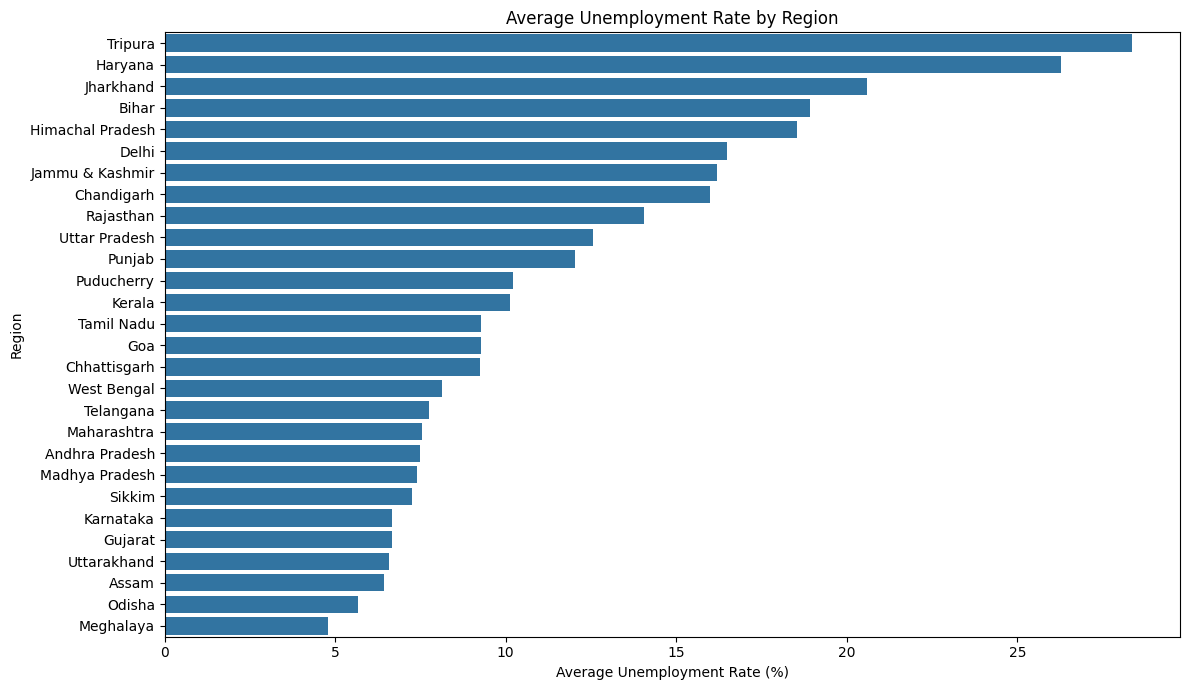

In [16]:
# Plot region-wise average unemployment rate
plt.figure(figsize=(12, 7))

sns.barplot(
    x=region_unemployment.values,
    y=region_unemployment.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

- **Tripura** recorded the highest average unemployment rate at approximately **28.35%**, followed by **Haryana** at **26.28%**.
- **Jharkhand, Bihar, and Himachal Pradesh** also showed relatively high average unemployment rates, all above 18%.
- **Meghalaya** recorded the lowest average unemployment rate at approximately **4.80%** among the regions in the dataset.
- The considerable variation across regions indicates that unemployment levels were not uniform across India during the observed period.

### 5.2 Month-wise Unemployment Trend

The average unemployment rate is analyzed across months to identify temporal changes and observe how unemployment varied during different periods of the year.

In [17]:
# Calculate average unemployment rate for each month-year
monthly_unemployment = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

# Convert the period index to timestamps for plotting
monthly_unemployment.index = monthly_unemployment.index.to_timestamp()

monthly_unemployment

Date
2019-05-01     8.874259
2019-06-01     9.303333
2019-07-01     9.033889
2019-08-01     9.637925
2019-09-01     9.051731
2019-10-01     9.900909
2019-11-01     9.868364
2019-12-01     9.497358
2020-01-01     9.950755
2020-02-01     9.964717
2020-03-01    10.700577
2020-04-01    23.641569
2020-05-01    24.875294
2020-06-01    11.903600
Freq: MS, Name: Estimated Unemployment Rate (%), dtype: float64

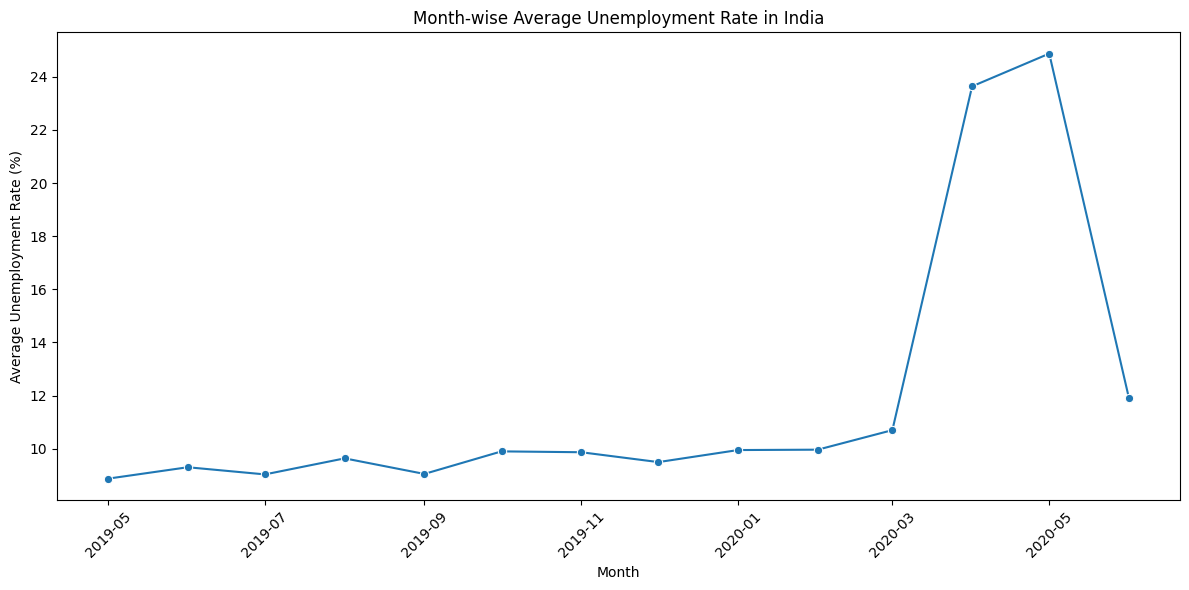

In [18]:
# Plot the month-wise unemployment trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_unemployment.index,
    y=monthly_unemployment.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

- The average unemployment rate remained relatively stable at around **9–10%** from May 2019 to February 2020.
- It increased slightly to approximately **10.70% in March 2020**.
- A sharp rise occurred in **April 2020**, when the average unemployment rate reached approximately **23.64%**.
- The rate peaked at approximately **24.88% in May 2020**, the highest monthly average in the dataset.
- By **June 2020**, the unemployment rate declined substantially to approximately **11.90%**, indicating a partial recovery after the sharp increase during April and May.
- The timing of this spike coincides with the COVID-19 lockdown period in India, suggesting a strong pandemic-related disruption to employment.

### 5.3 Unemployment Trends in Selected Major States

To examine regional differences over time, unemployment trends are compared for three major states/regions: **Maharashtra, Delhi, and Karnataka**. This comparison helps identify how unemployment patterns changed across different regions, particularly around the COVID-19 period.

In [19]:
# Select three major states/regions for time-series analysis
selected_states = ["Maharashtra", "Delhi", "Karnataka"]

state_data = df[df["Region"].isin(selected_states)]

# Calculate average unemployment rate by date and region
state_trends = (
    state_data.groupby(["Date", "Region"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

state_trends.head()

,Date,Region,Estimated Unemployment Rate (%)
0,2019-05-31,Delhi,12.435
1,2019-05-31,Karnataka,6.010
2,2019-05-31,Maharashtra,4.875
3,2019-06-30,Delhi,11.045
4,2019-06-30,Karnataka,5.490


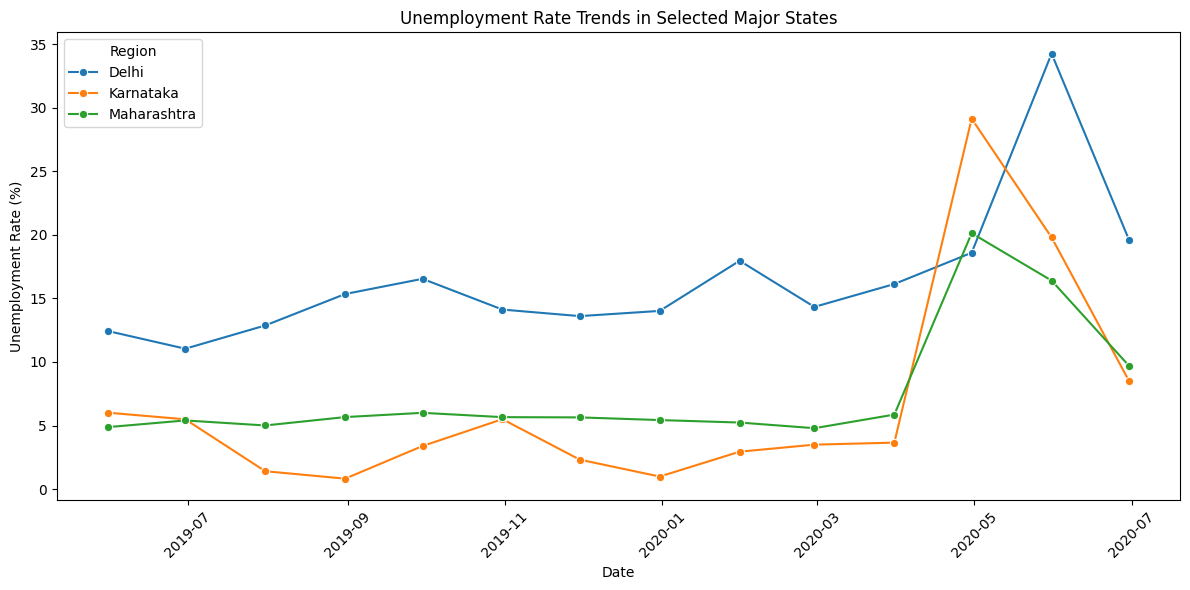

In [20]:
# Plot unemployment trends for selected states
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=state_trends,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Trends in Selected Major States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Region")

plt.tight_layout()
plt.show()

### Observation

- Before the COVID-19 period, **Delhi generally had a higher unemployment rate** than Maharashtra and Karnataka.
- All three regions experienced a sharp increase in unemployment during the COVID-19 period.
- **Karnataka** showed a major spike around May 2020, reaching approximately **29%**.
- **Maharashtra** also experienced a substantial increase, reaching approximately **20%** around May 2020.
- **Delhi recorded the highest peak among the three regions**, rising to approximately **34%** around June 2020.
- Unemployment rates subsequently declined across all three regions, indicating movement toward recovery, although the timing and magnitude of the impact differed considerably by region.

### 5.4 Top 10 Regions with the Highest Average Unemployment Rate

The ten regions with the highest average unemployment rates are identified to highlight the areas that experienced the greatest unemployment levels during the period covered by the dataset.

In [21]:
# Select the top 10 regions with the highest average unemployment rate
top_10_regions = region_unemployment.head(10)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

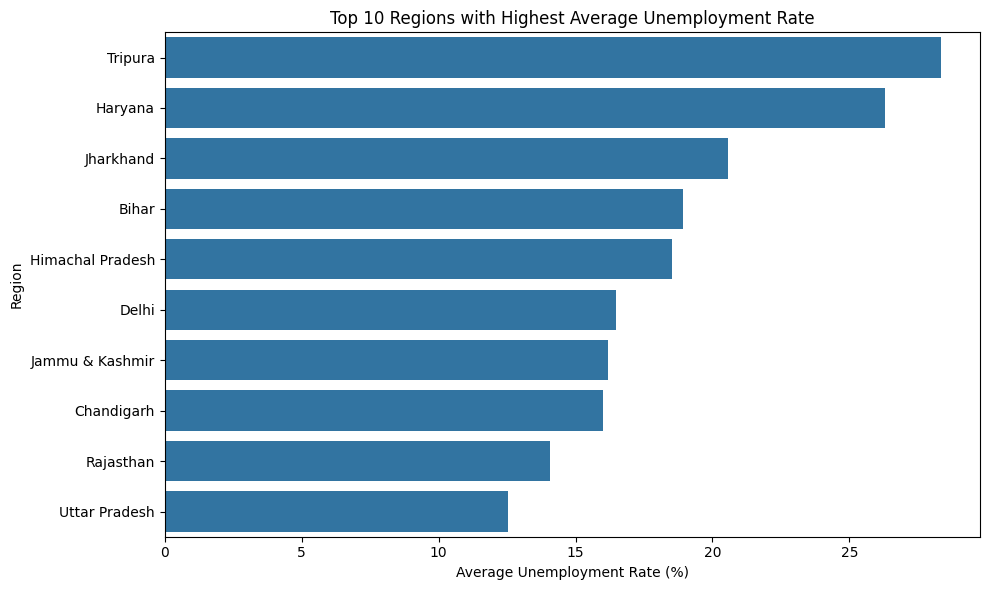

In [22]:
# Plot the top 10 regions with the highest average unemployment rate
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

- **Tripura** and **Haryana** had the highest average unemployment rates, at approximately **28.35%** and **26.28%**, respectively.
- **Jharkhand** ranked third with an average unemployment rate of approximately **20.59%**.
- The top 10 regions show substantial differences in average unemployment levels, highlighting regional variation in unemployment across India during the period covered by the dataset.

### 5.5 Correlation Analysis

A correlation heatmap is used to examine the relationships among the numerical employment indicators available in the dataset: **Estimated Unemployment Rate**, **Estimated Employed**, and **Estimated Labour Participation Rate**.

> **Note:** The dataset provides the estimated number of employed individuals rather than an employment rate. Therefore, `Estimated Employed` is used in the correlation analysis.

In [23]:
# Select numerical employment-related features
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


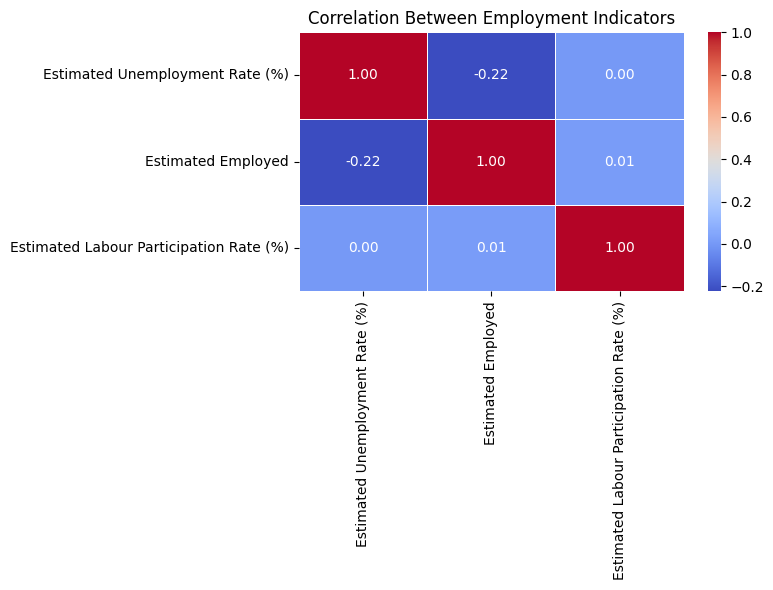

In [24]:
# Plot the correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

### Observation

- The unemployment rate and estimated number of employed individuals show a **weak negative correlation of approximately -0.22**, indicating that higher unemployment rates tend to be associated with lower employment counts, although the relationship is not strong.
- The unemployment rate and labour participation rate have a correlation close to **0.00**, indicating almost no linear relationship in this dataset.
- Estimated employment and labour participation rate also show almost no linear correlation, with a coefficient of approximately **0.01**.
- Overall, the correlation analysis suggests that no strong linear relationship exists among these three indicators in the dataset.

## 6. Impact of COVID-19 on Unemployment

To examine the impact of the COVID-19 pandemic on unemployment in India, the dataset is divided into two periods:

- **Pre-COVID Period:** Observations before March 2020
- **COVID Period:** Observations from March 2020 onward

The average unemployment rates during these periods are compared to understand how unemployment changed around the onset of the pandemic.

In [25]:
# Classify observations into Pre-COVID and COVID periods
df["Period"] = np.where(
    df["Date"] < "2020-03-01",
    "Pre-COVID",
    "COVID Period"
)

# Check the number of observations in each period
df["Period"].value_counts()

Period
Pre-COVID       536
COVID Period    204
Name: count, dtype: int64

In [26]:
# Calculate the average unemployment rate for each period
covid_comparison = (
    df.groupby("Period")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(["Pre-COVID", "COVID Period"])
)

covid_comparison

Period
Pre-COVID        9.509534
COVID Period    17.774363
Name: Estimated Unemployment Rate (%), dtype: float64

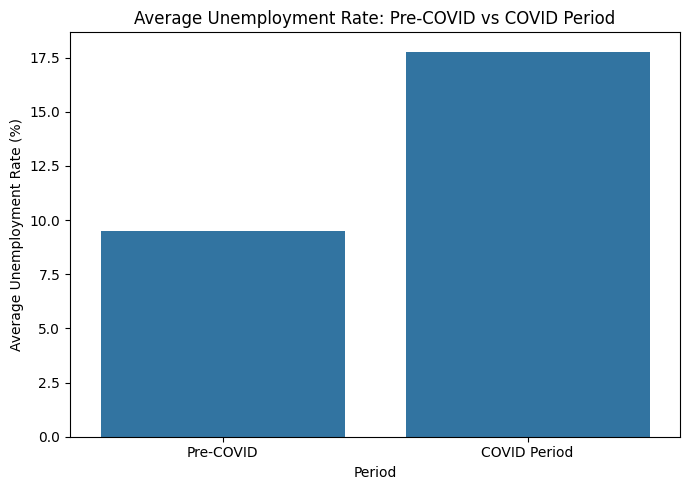

In [27]:
# Plot Pre-COVID vs COVID-period unemployment rates
plt.figure(figsize=(7, 5))

sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison.values
)

plt.title("Average Unemployment Rate: Pre-COVID vs COVID Period")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [28]:
# Calculate the change in average unemployment rate
pre_covid_rate = covid_comparison["Pre-COVID"]
covid_rate = covid_comparison["COVID Period"]

percentage_increase = ((covid_rate - pre_covid_rate) / pre_covid_rate) * 100

print(f"Pre-COVID Average Unemployment Rate: {pre_covid_rate:.2f}%")
print(f"COVID Period Average Unemployment Rate: {covid_rate:.2f}%")
print(f"Percentage Increase: {percentage_increase:.2f}%")

Pre-COVID Average Unemployment Rate: 9.51%
COVID Period Average Unemployment Rate: 17.77%
Percentage Increase: 86.91%


### Observation

- The average unemployment rate during the **Pre-COVID period** was approximately **9.51%**.
- During the defined **COVID period**, the average unemployment rate increased to approximately **17.77%**.
- This represents an increase of approximately **86.91%** compared with the Pre-COVID average.
- The month-wise analysis showed that the sharpest rise occurred during **April and May 2020**, when the average unemployment rate exceeded 23%.
- These findings indicate a substantial labour-market disruption during the early months of the COVID-19 pandemic, followed by signs of recovery by June 2020.

## 7. Conclusion

The exploratory analysis of unemployment data revealed significant regional and temporal variations in unemployment across India.

- Tripura and Haryana recorded the highest average unemployment rates among the regions represented in the dataset.
- Unemployment remained relatively stable during most of 2019 and early 2020 before increasing sharply during April and May 2020.
- The comparison of Maharashtra, Delhi, and Karnataka showed that the magnitude and timing of unemployment changes varied across regions.
- The correlation analysis found no strong linear relationships among the selected employment indicators.
- The average unemployment rate increased from approximately **9.51% in the Pre-COVID period to 17.77% during the defined COVID period**, representing an increase of approximately **86.91%**.
- By June 2020, the unemployment rate had declined considerably from its peak, indicating signs of an early recovery.

Overall, the analysis highlights the substantial disruption in unemployment patterns during the early COVID-19 period and demonstrates how exploratory data analysis and visualization can be used to identify regional and temporal trends in employment data.